In [2]:
!pip install yfinance tensorflow scikit-learn matplotlib

In [3]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [4]:
# Cell 3
df = yf.download("AAPL", start="2018-01-01", end="2024-01-01")
df.head()

/tmp/ipykernel_951/1178558844.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2018-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2018-01-02,40.304176,40.313537,39.602258,39.812835,102223600
2018-01-03,40.297150,40.839968,40.233980,40.367342,118071600
2018-01-04,40.484337,40.587286,40.262063,40.369689,89738400
2018-01-05,40.945255,41.031824,40.489009,40.580258,94640000
2018-01-08,40.793186,41.087991,40.694914,40.793186,82271200


In [5]:
data = df[['Close']].values

scaler = MinMaxScaler()
data = scaler.fit_transform(data)

In [6]:
X, y = [], []

for i in range(50, len(data)):
    X.append(data[i-50:i])
    y.append(data[i])

X, y = np.array(X), np.array(y)

In [7]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X.shape[1],1)),
    LSTM(50),
    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
model.compile(optimizer='adam', loss='mse')

history = model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

Epoch 1/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - loss: 0.0275 - val_loss: 0.0058
Epoch 2/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0012 - val_loss: 0.0020
Epoch 3/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 9.9528e-04 - val_loss: 0.0016
Epoch 4/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 9.6127e-04 - val_loss: 0.0014
Epoch 5/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 9.7932e-04 - val_loss: 0.0027


In [10]:
pred = model.predict(X_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step


In [11]:
pred = scaler.inverse_transform(pred)
y_test_actual = scaler.inverse_transform(y_test)

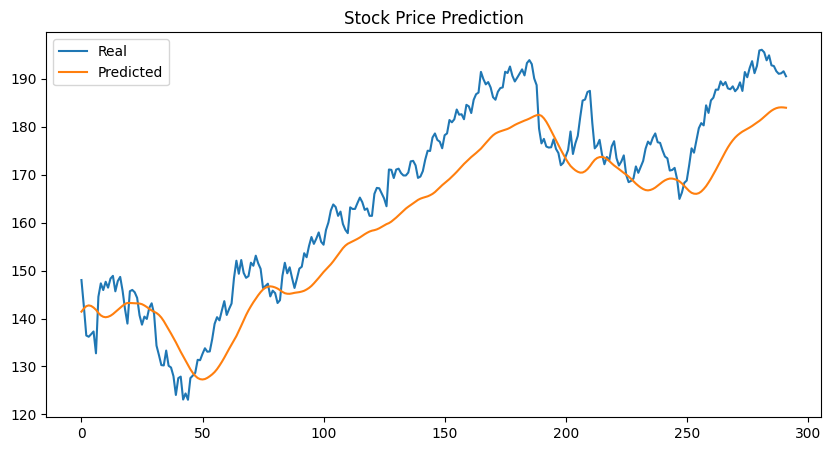

In [12]:
plt.figure(figsize=(10,5))
plt.plot(y_test_actual, label='Real')
plt.plot(pred, label='Predicted')
plt.legend()
plt.title("Stock Price Prediction")
plt.show()

In [13]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test_actual, pred))
print("RMSE:", rmse)

RMSE: 8.475144920218256
